## Descriptions
This script is for plotting all the WRF output from Yagi (2024) simulations

In [1]:
import numpy as np
import modPlotWRF as wrf
import importlib 

## Plot 3D fields

In [18]:
# open input file
#df,dx,nx,ny,nz = wrf.loadWRF('wrfout_d01_2024-09-03_15:00:00')
df,dx,nx,ny,nz = wrf.loadWRF('wrfout_d01_2024-09-06_00:00:00')
df

A-grid dim (dx,nx,ny,nz) for wrfout_d01_2024-09-06_00:00:00 are (np.float32(9000.0), 740, 495, 30)


<xarray.Dataset> Size: 879MB
Dimensions:                (Time: 1, south_north: 495, west_east: 740,
                            bottom_top: 30, bottom_top_stag: 31,
                            soil_layers_stag: 4, west_east_stag: 741,
                            south_north_stag: 496, seed_dim_stag: 2)
Coordinates:
    XLAT                   (Time, south_north, west_east) float32 1MB -4.265 ...
    XLONG                  (Time, south_north, west_east) float32 1MB 93.89 ....
    XTIME                  (Time) datetime64[ns] 8B 2024-09-06
    XLAT_U                 (Time, south_north, west_east_stag) float32 1MB -4...
    XLONG_U                (Time, south_north, west_east_stag) float32 1MB 93...
    XLAT_V                 (Time, south_north_stag, west_east) float32 1MB -4...
    XLONG_V                (Time, south_north_stag, west_east) float32 1MB 93...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                                west_east_stag, south_north_stag, seed_dim_stag
Data variables: (12/169)
    Times                  (Time) |S19 19B b'2024-09-06_00:00:00'
    LU_INDEX               (Time, south_north, west_east) float32 1MB 17.0 .....
    ZNU                    (Time, bottom_top) float32 120B 0.9415 ... 0.002745
    ZNW                    (Time, bottom_top_stag) float32 124B 1.0 ... 0.0
    ZS                     (Time, soil_layers_stag) float32 16B 0.05 ... 1.5
    DZS                    (Time, soil_layers_stag) float32 16B 0.1 0.3 0.6 1.0
    ...                     ...
    PCB                    (Time, south_north, west_east) float32 1MB 0.0 ......
    PC                     (Time, south_north, west_east) float32 1MB 0.0 ......
    LANDMASK               (Time, south_north, west_east) float32 1MB 0.0 ......
    LAKEMASK               (Time, south_north, west_east) float32 1MB 0.0 ......
    SST                    (Time, south_north, west_east) float32 1MB 301.5 ....
    SST_INPUT              (Time, south_north, west_east) float32 1MB 0.0 ......
Attributes: (12/136)
    TITLE:                            OUTPUT FROM WRF V4.7.1 MODEL
    START_DATE:                      2024-09-02_00:00:00
    SIMULATION_START_DATE:           2024-09-02_00:00:00
    WEST-EAST_GRID_DIMENSION:        741
    SOUTH-NORTH_GRID_DIMENSION:      496
    BOTTOM-TOP_GRID_DIMENSION:       31
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      0
    ETAC:                            0.0

In [50]:
# create an object for WRF 3D variables
importlib.reload(wrf)
p3d = wrf.var3D(nz=nz,ny=ny,nx=nx,dx=dx/1000)
p3d.__dict__

{'nx': 740,
 'ny': 495,
 'nz': 30,
 'nx1': 741,
 'ny1': 496,
 'nz1': 31,
 'dx': np.float32(9.0)}

Plotting default color range


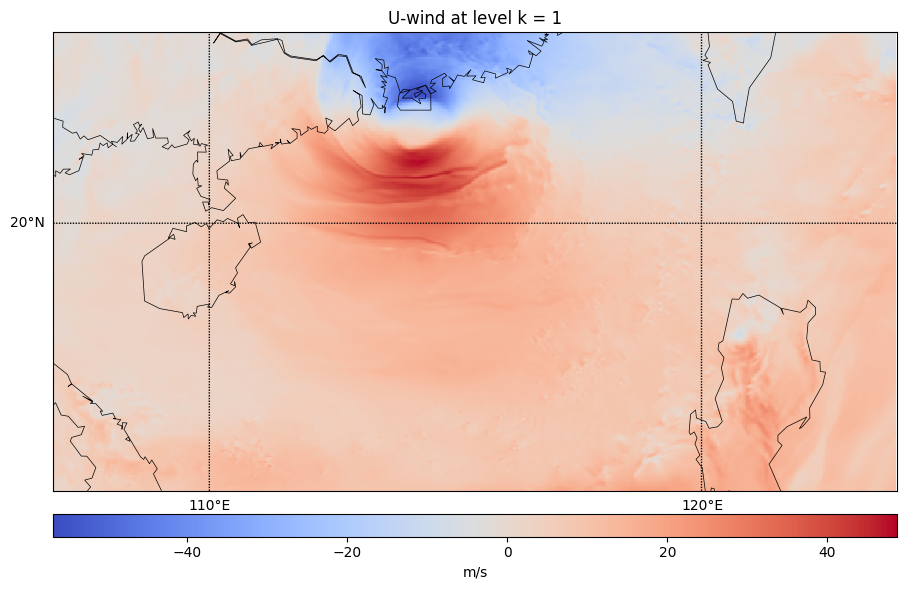

In [6]:
# plot u
u1 = p3d.shiftU3D(df.U.values)
clevs = [-999]                             # default color levels and scheme
#clevs=[-20, -15, -10,-5,0,5,10,15,20], # my own color levels
min_color = (0,0.5,0)                   # my own color scheme
max_color = (0,0.9,0)                   # my own color scheme
title = "U-wind"
colorbar_label = "m/s"
plevel = 1                              # level to plot
p3d.plot_zlevel_world3D(df,u1,ilev=plevel,
                         slat=0,elat=31,slon=100,elon=135,
                         title=title,clevs=clevs,                              
                         minc=min_color,maxc=max_color, 
                         labels=colorbar_label)

Plotting customized color range


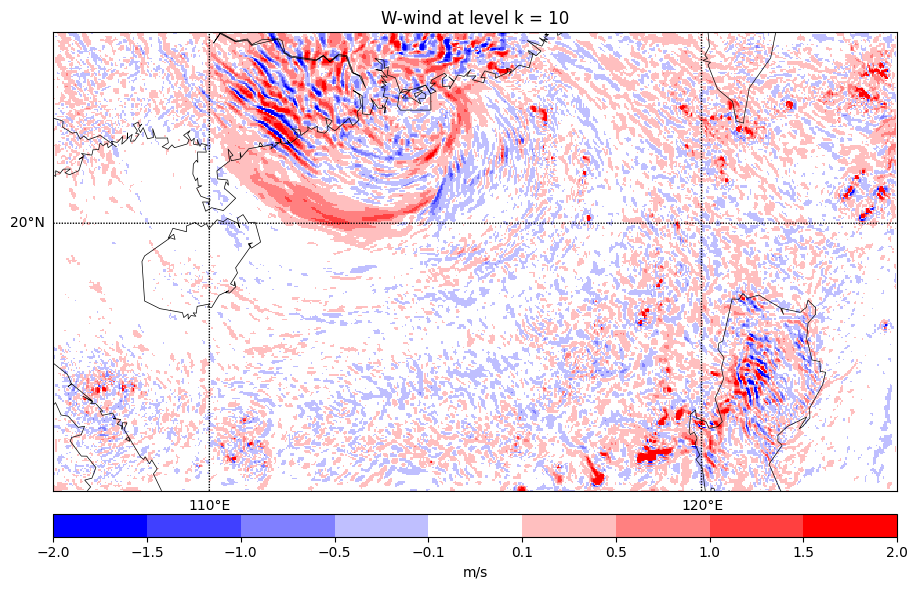

In [7]:
importlib.reload(wrf)
w1 = df.W.values[0]
#clevs = [-999]                       # default color levels and scheme
clevs=[-2.0, -1.5, -1.0,-0.5,-0.1, 0.1, 0.5, 1.0, 1.5, 2.0] # my own color levels
min_color = (0,0,1)                   # my own color scheme
max_color = (1,0,0)                   # my own color scheme
title = "W-wind"
colorbar_label = "m/s"
plevel = 10                           # level to plot
p3d.plot_zlevel_world3D(df,w1,ilev=plevel,
                         slat=0,elat=31,slon=100,elon=135,
                         title=title,clevs=clevs,                              
                         minc=min_color,maxc=max_color, 
                         labels=colorbar_label)

Plotting customized color range


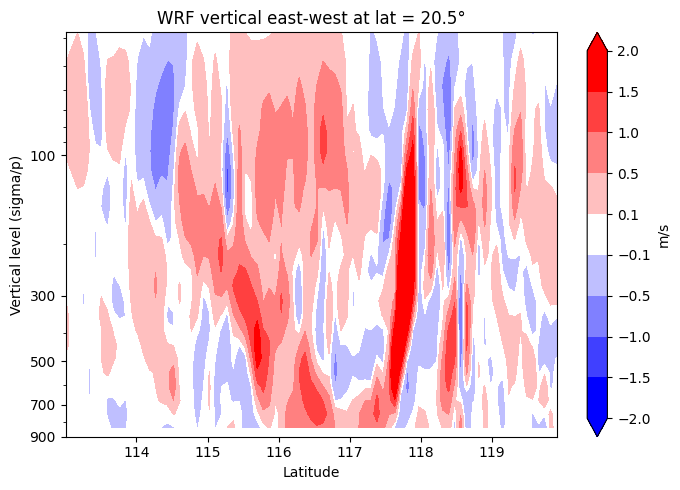

In [54]:
# plot vertical cross section
importlib.reload(wrf)
w1 = df.W.values[0]
w2 = (w1[:nz] + w1[1:nz+1])/2.
#clevs = [-999]                       # default color levels and scheme
clevs=[-2.0, -1.5, -1.0,-0.5,-0.1, 0.1, 0.5, 1.0, 1.5, 2.0] # my own color levels
min_color = (0,0,1)                   # my own color scheme
max_color = (1,0,0)                   # my own color scheme
title = "W-wind"
colorbar_label = "m/s"
plevel = 10                           # level to plot
p3d.plot_xSection_grid3D(df,w2,xlat=20.5,xlon=-99,
                         slat=0,elat=31,slon=113,elon=120,
                         lev1=1,lev2=25,
                         clevs=clevs,ticks=[-1,0,1],
                         labels="m/s",
                         title="WRF vertical east-west",
                         minc=min_color,
                         maxc=max_color,
                         zlev="s",option="shading",cfont=12)

(30, 333, 612)
Plotting customized color range


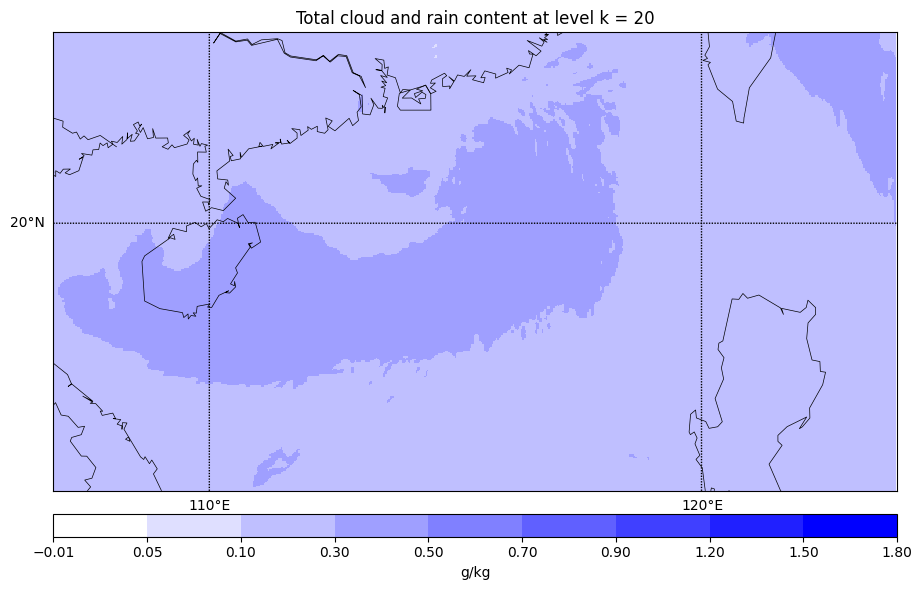

In [9]:
importlib.reload(wrf)
cloud = df.QRAIN.values[0]+df.QCLOUD.values[0]
print(cloud.shape)
#clevs = [-999]                       # default color levels and scheme
clevs=[-0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 1.2, 1.5, 1.8] # my own color levels
min_color = (1,1,1)                   # my own color scheme
max_color = (0,0,1)                   # my own color scheme
title = "Total cloud and rain content"
colorbar_label = "g/kg"
plevel = 20                            # level to plot
p3d.plot_zlevel_world3D(df,cloud*1e3,ilev=plevel,
                         slat=0,elat=31,slon=100,elon=135,
                         title=title,clevs=clevs,                              
                         minc=min_color,maxc=max_color, 
                         labels=colorbar_label)

## Plot 2D fields

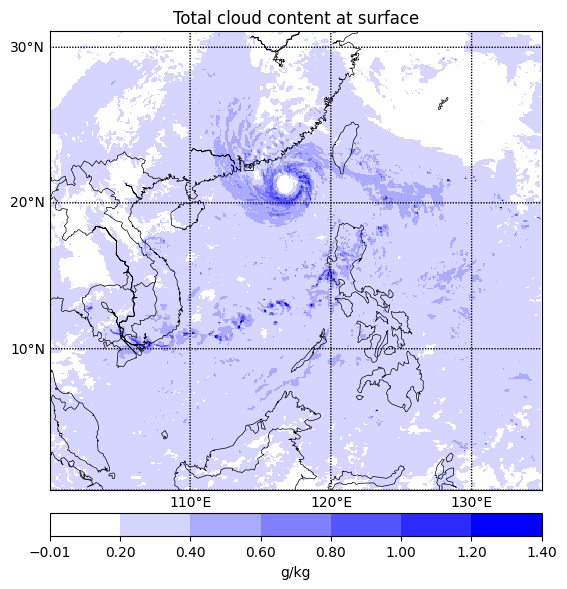

In [19]:
# plot 2D total cloud
importlib.reload(wrf)
p2d = wrf.var2D(ny=ny,nx=nx,dx=dx/1000)
cloud_total = np.sum(df.QCLOUD.values[0], axis=0) 
clevs=[-0.01, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4] # my own color levels
min_color = (1,1,1)                   # my own color scheme
max_color = (0,0,1)                   # my own color scheme
title = "Total cloud and rain content"
colorbar_label = "g/kg"
p2d.plot_surface_world2D(df,cloud_total*1e2,
                         slat=0,elat=31,slon=100,elon=135,
                         title="Total cloud content",
                         clevs=clevs,                              
                         minc=min_color,
                         maxc=max_color,
                         labels="g/kg")

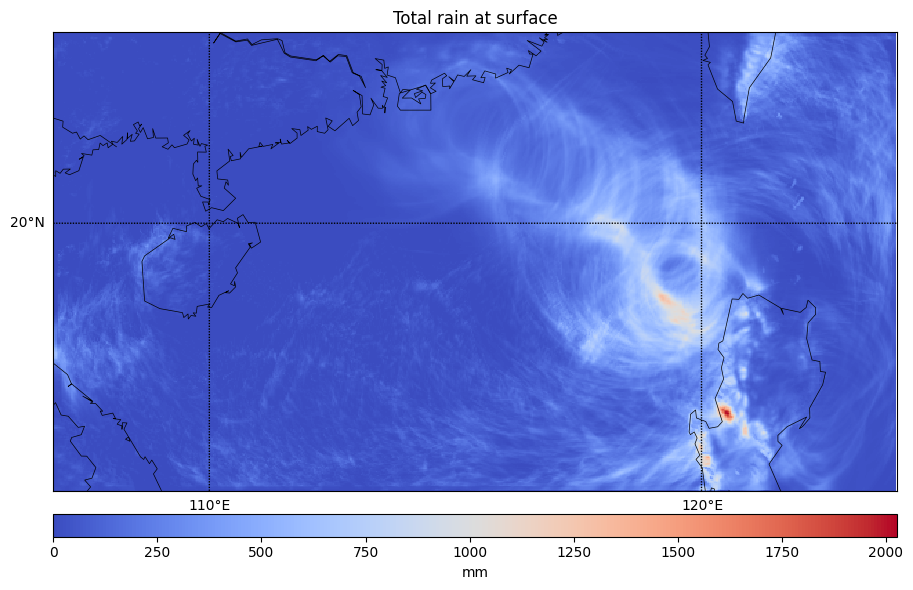

In [10]:
# plot 2D total rain
importlib.reload(wrf)
p2d = wrf.var2D(ny=ny,nx=nx,dx=dx/1000)
rain_total = df.RAINC[0] + df.RAINNC[0]
olr = df.OLR[0]
p2d.plot_surface_world2D(df,rain_total,
                        slat=0,elat=31,slon=100,elon=135,
                        title="Total rain",
                        clevs=[0], # default color levels and scheme                          
                        #clevs=[-20, -15, -10,-5,0,5,10,15,20], # my own color levels
                        minc=(0,0,0),maxc=(0,1,0), # my own color scheme
                        labels="mm")

## This is an example for initial condition comparision

In [69]:
# open input file
df,dx,nx,ny,nz = wrf.loadWRF('wrfinput_d01.new')
# open a new file for comparison
df2,*_ = wrf.loadWRF('wrfinput_d01.old')
print(f"dx,nx,ny,nz are: {dx,nx,ny,nz}")
#wrf.__dict__

A-grid dim (dx,nx,ny,nz) for wrfinput_d01.new are (36000.0, 150, 150, 30)
A-grid dim (dx,nx,ny,nz) for wrfinput_d01.old are (36000.0, 150, 150, 30)
dx,nx,ny,nz are: (36000.0, 150, 150, 30)


In [53]:
# create an object for WRF 3D variables
p3d = wrf.var3D(nz=30,ny=150,nx=150,dx=36)
p3d.__dict__

{'nx': 150, 'ny': 150, 'nz': 30, 'nx1': 151, 'ny1': 151, 'nz1': 31, 'dx': 36}

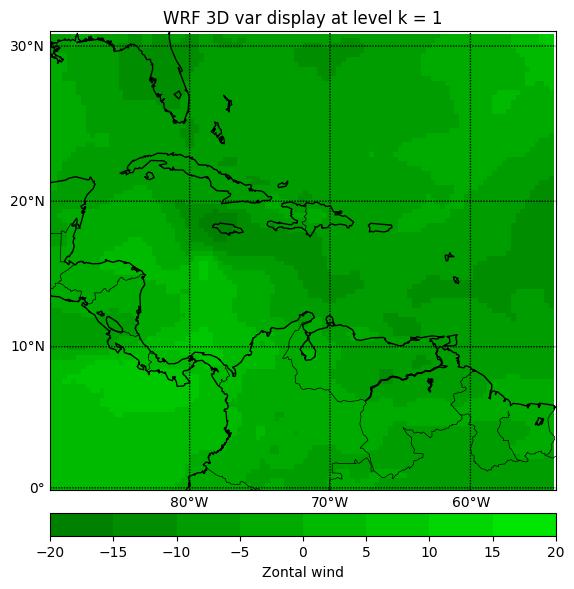

In [67]:
# plot u
importlib.reload(wrf)
p3d = wrf.var3D(nz=30,ny=150,nx=150,dx=36)
u1 = p3d.shiftU3D(df.U.values)
p3d.plot_shading_world3D(df,u1,ilev=1,
                             slat=0,elat=31,slon=-90,elon=-30,
                             title="WRF 3D var display",
                             clevs=[-20, -15, -10,-5,0,5,10,15,20],
                             #clevs=[0],
                             minc=(0,0.5,0),maxc=(0,0.9,0),
                             labels="Zontal wind")

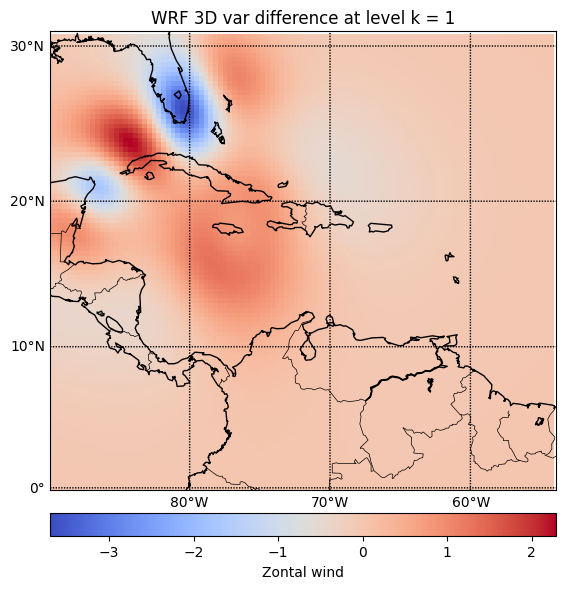

In [61]:
# plot u_new-u_old
importlib.reload(wrf)
p3d = wrf.var3D(nz=30,ny=150,nx=150,dx=36)
u2 = p3d.shiftU3D(df2.U.values)
p3d.plot_shading_world3D(df,u1-u2,ilev=1,
                             slat=0,elat=31,slon=-90,elon=-30,
                             title="WRF 3D var difference",
                             #clevs=[-2.0, -1.5, -1.0,-0.5,0,0.5,1.0,1.5,2.0],
                             clevs=[0],
                             minc=(0,0.4,0),maxc=(0,0.9,0),
                             labels="Zontal wind")

<class 'numpy.ndarray'> (30, 150, 150)


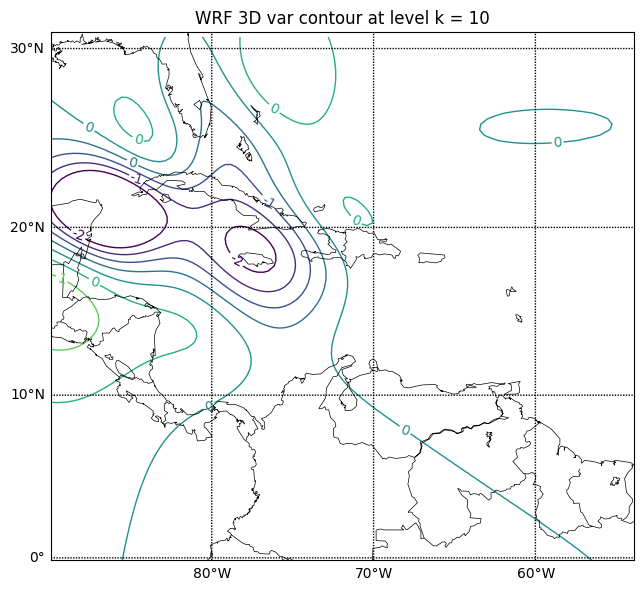

In [57]:
# plot contour u_new-u_old (analysis increment)
importlib.reload(wrf)
p3d = wrf.var3D(nz=30,ny=150,nx=150,dx=36)
u1 = p3d.shiftU3D(df['U'].values)
print(type(u1),u1.shape)
p3d.plot_contour_world3D(df,u1-u2,ilev=10,
                             slat=0,elat=31,slon=-90,elon=-30,
                             title="WRF 3D var contour",
                             clevs=[-2.0, -1.5, -1.0,-0.5,0,0.5,1.0,1.5,2.0],
                             #clevs=[0],
                             minc=(0,0.4,0),maxc=(0,0.9,0),
                             maplinewidth=0.5)

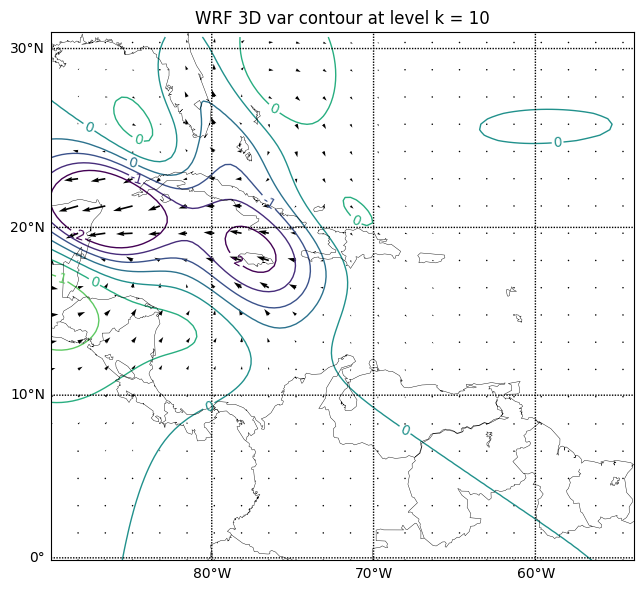

In [70]:
# plot contour u_new-u_old (analysis increment)
importlib.reload(wrf)
p3d = wrf.var3D(nz=30,ny=150,nx=150,dx=36)
u1 = p3d.shiftU3D(df.U.values)
v1 = p3d.shiftV3D(df.V.values)
u2 = p3d.shiftU3D(df2.U.values)
v2 = p3d.shiftV3D(df2.V.values)
p3d.plot_contour_world3Dvector(df,u1-u2,u1-u2,v1-v2,ilev=10,
                             slat=0,elat=31,slon=-90,elon=-30,
                             title="WRF 3D var contour",
                             clevs=[-2.0, -1.5, -1.0,-0.5,0,0.5,1.0,1.5,2.0],
                             #clevs=[0],                             ,
                             scale=100,skipx=5,skipy=5,maplinewidth=0.3)

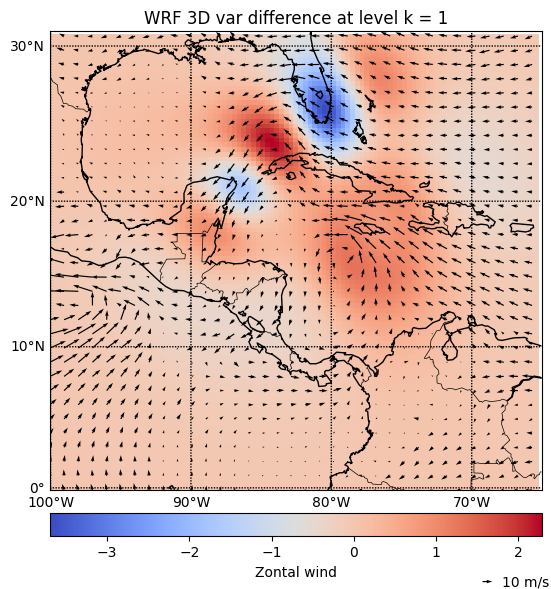

In [59]:
# plot u_new-u_old in shading (analysis increment)
importlib.reload(wrf)
p3d = wrf.var3D(nz=30,ny=150,nx=150,dx=36)
p3d.plot_shading_world3Dvector(df,u1-u2,ilev=1,
                             slat=0,elat=31,slon=-100,elon=-65,
                             title="WRF 3D var difference",
                             #clevs=[-2.0, -1.5, -1.0,-0.5,0,0.5,1.0,1.5,2.0],
                             clevs=[0],
                             minc=(0,0.4,0),maxc=(0,0.9,0),
                             labels="Zontal wind",scale=500,
                             skipx=3,skipy=3)